CIFAR-10 classification

Changelog

version 4
- Add `momentum` and `weight_decay` to optimizer
- set `batch_size = 128`

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

Dataset

In [2]:
dataset = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = dataset.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step


In [3]:
print(f"x_train:", "Shape", x_train.shape, ", Data Type", x_train.dtype, ", Min", x_train.min(), ", Max", x_train.max())
print(f"y_train:", "Shape", y_train.shape, ", Data Type", y_train.dtype, ", Min", y_train.min(), ", Max", y_train.max())
print(f"x_test:", "Shape", x_test.shape, ", Data Type", x_test.dtype, ", Min", x_test.min(), ", Max", x_test.max())
print(f"y_test:", "Shape", y_test.shape, ", Data Type", y_test.dtype, ", Min", y_test.min(), ", Max", y_test.max())

x_train: Shape (50000, 32, 32, 3) , Data Type uint8 , Min 0 , Max 255
y_train: Shape (50000, 1) , Data Type uint8 , Min 0 , Max 9
x_test: Shape (10000, 32, 32, 3) , Data Type uint8 , Min 0 , Max 255
y_test: Shape (10000, 1) , Data Type uint8 , Min 0 , Max 9


In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
print(f"x_train:", "Shape", x_train.shape, ", Data Type", x_train.dtype, ", Min", x_train.min(), ", Max", x_train.max())
print(f"x_test:", "Shape", x_test.shape, ", Data Type", x_test.dtype, ", Min", x_test.min(), ", Max", x_test.max())

x_train: Shape (50000, 32, 32, 3) , Data Type float64 , Min 0.0 , Max 1.0
x_test: Shape (10000, 32, 32, 3) , Data Type float64 , Min 0.0 , Max 1.0


In [6]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [7]:
print(f"y_train:", "Shape", y_train.shape, ", Data Type", y_train.dtype, ", Min", y_train.min(), ", Max", y_train.max())
print(f"y_test:", "Shape", y_test.shape, ", Data Type", y_test.dtype, ", Min", y_test.min(), ", Max", y_test.max())

y_train: Shape (50000, 10) , Data Type float64 , Min 0.0 , Max 1.0
y_test: Shape (10000, 10) , Data Type float64 , Min 0.0 , Max 1.0


In [8]:
# Split train data to train/val data
x_train, x_val = x_train[:45000], x_train[45000:]
y_train, y_val = y_train[:45000], y_train[45000:]

In [9]:
print(f"x_train:", "Shape", x_train.shape, ", Data Type", x_train.dtype, ", Min", x_train.min(), ", Max", x_train.max())
print(f"y_train:", "Shape", y_train.shape, ", Data Type", y_train.dtype, ", Min", y_train.min(), ", Max", y_train.max())
print(f"x_val:", "Shape", x_val.shape, ", Data Type", x_val.dtype, ", Min", x_val.min(), ", Max", x_val.max())
print(f"y_val:", "Shape", y_val.shape, ", Data Type", y_val.dtype, ", Min", y_val.min(), ", Max", y_val.max())

x_train: Shape (45000, 32, 32, 3) , Data Type float64 , Min 0.0 , Max 1.0
y_train: Shape (45000, 10) , Data Type float64 , Min 0.0 , Max 1.0
x_val: Shape (5000, 32, 32, 3) , Data Type float64 , Min 0.0 , Max 1.0
y_val: Shape (5000, 10) , Data Type float64 , Min 0.0 , Max 1.0


Model

In [10]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((32, 32, 3)),
    tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,074 (609.66 KB)

 Trainable params: 156,074 (609.66 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, weight_decay=0.0001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy'])

In [13]:
epochs = 20
batch_size = 128
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=batch_size)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.2330 - loss: 2.0685 - val_accuracy: 0.4712 - val_loss: 1.4895
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4715 - loss: 1.4644 - val_accuracy: 0.5514 - val_loss: 1.2647
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5526 - loss: 1.2580 - val_accuracy: 0.6096 - val_loss: 1.1169
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6060 - loss: 1.1077 - val_accuracy: 0.6234 - val_loss: 1.0565
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6473 - loss: 1.0002 - val_accuracy: 0.6420 - val_loss: 1.0188
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6783 - loss: 0.9204 - val_accuracy: 0.6358 - val_loss: 1.0436
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7027 - loss: 0.8577 - val_accuracy: 0.6774 - val_loss: 0.9499
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7205 - loss: 0.7983 - val_accuracy: 0

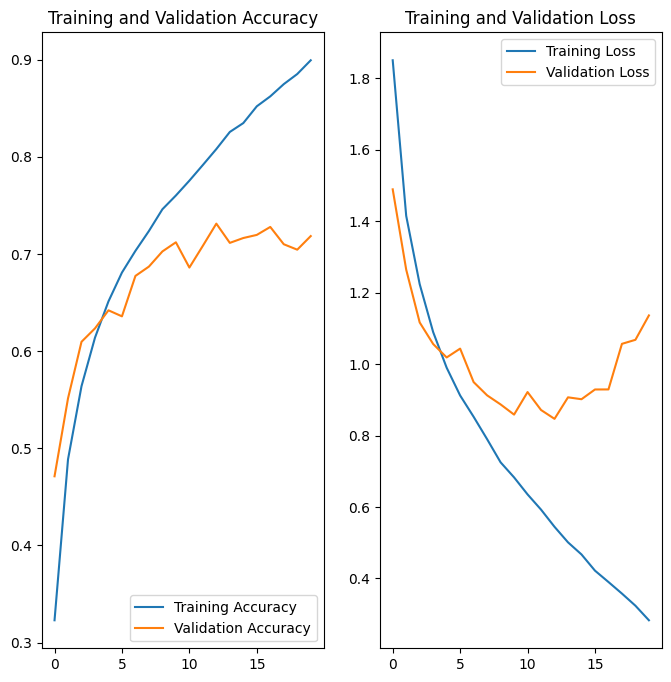

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [15]:
model.evaluate(x_test,  y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7010 - loss: 1.2501


[1.2680716514587402, 0.6983000040054321]